# Caso grupal: Detección de anomalías y técnicas de agrupamiento (CTG)

**Dataset:** Cardiotocography (CTG.csv)  
**Objetivo:** realizar EDA, tratar missing, detectar anomalías (por atributo e instancia) y generar clústeres, comparando modelos y concluyendo.




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


PATH = r"../datasets/CTG.csv"

df = pd.read_csv(PATH)
print("Shape:", df.shape)
df.head()


Shape: (2129, 40)


,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,5/3/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,5/3/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


## 1) Análisis descriptivo (EDA)

### 1.1 Tipos de variables
- **Identificadores / texto:** `FileName`, `Date`, `SegFile`
- **Etiquetas (categóricas numéricas):** `CLASS`, `NSP` (se usan para análisis, pero NO para clustering/anomalías)
- **Resto:** variables numéricas de señales.

En esta sección:
1) Estadísticos descriptivos para variables numéricas  
2) Frecuencias para variables categóricas  
3) Matriz de correlaciones y análisis


In [2]:
# Separación de columnas
id_cols = ['FileName', 'Date', 'SegFile']
label_cols = ['CLASS', 'NSP']  # etiquetas
num_cols = [c for c in df.columns if c not in id_cols]

# Estadísticos de numéricas (incluye labels; luego si quieres, exclúyelas)
desc = df[num_cols].describe().T
desc[['count','mean','std','min','25%','50%','75%','max']].head(10)


,count,mean,std,min,25%,50%,75%,max
b,2126.0,878.439793,894.084748,0.0,55.0,538.0,1521.00,3296.0
e,2126.0,1702.877234,930.919143,287.0,1009.0,1241.0,2434.75,3599.0
LBE,2126.0,133.303857,9.840844,106.0,126.0,133.0,140.00,160.0
LB,2126.0,133.303857,9.840844,106.0,126.0,133.0,140.00,160.0
AC,2126.0,2.722484,3.560850,0.0,0.0,1.0,4.00,26.0
FM,2127.0,7.503056,39.030452,0.0,0.0,0.0,2.00,564.0
UC,2127.0,3.669017,2.877148,0.0,1.0,3.0,5.00,23.0
ASTV,2127.0,47.008933,17.210648,12.0,32.0,49.0,61.00,87.0
MSTV,2127.0,1.335449,0.891543,0.2,0.7,1.2,1.70,7.0
ALTV,2127.0,9.884814,18.476534,0.0,0.0,0.0,11.00,91.0


In [3]:
# Variables categóricas
cat_cols = [c for c in id_cols if c in df.columns] + [c for c in label_cols if c in df.columns]

for c in cat_cols:
    print("\n==", c, "==")
    print(df[c].value_counts(dropna=False).head(20))



== FileName ==
FileName
S8001034.dsp    34
S7001029.dsp    33
S8001037.dsp    30
S8001038.dsp    26
S7001027.dsp    24
S8001035.dsp    23
S7001016.dsp    21
S0001094.dat    21
S8001031.dsp    20
S8001042.dsp    20
S0001084.dat    20
S7001024.dsp    19
S7001022.dsp    19
S7001023.dsp    19
S8001033.dsp    19
S0001056.dat    18
S7001018.dsp    18
S8001043.dsp    18
S0001085.dat    18
S0001095.dat    17
Name: count, dtype: int64

== Date ==
Date
2/22/1995     240
5/2/1996      160
7/18/1996     101
10/3/1996      92
5/3/1996       88
5/10/1998      85
10/6/1996      79
5/1/1996       79
6/6/1998       77
9/25/1996      74
1/8/1995       71
10/25/1997     70
1/4/1980       56
8/20/1996      55
5/6/1996       53
4/8/1998       53
11/26/1997     53
8/28/1996      52
12/9/1996      50
8/16/1996      43
Name: count, dtype: int64

== SegFile ==
SegFile
NaN            3
CTG0001.txt    1
CTG0002.txt    1
CTG0003.txt    1
CTG0004.txt    1
CTG0005.txt    1
CTG0006.txt    1
CTG0007.txt    1
CTG0008

### 1.3 Correlación entre variables numéricas

- Usamos correlación de Pearson en variables numéricas.
- Interpretación rápida:
  - **|corr| cercano a 1:** relación lineal fuerte.
  - **|corr| cercano a 0:** relación lineal débil.
- En CTG es común encontrar variables derivadas entre sí (por ejemplo estadísticas del FHR), lo cual puede generar correlaciones altas.


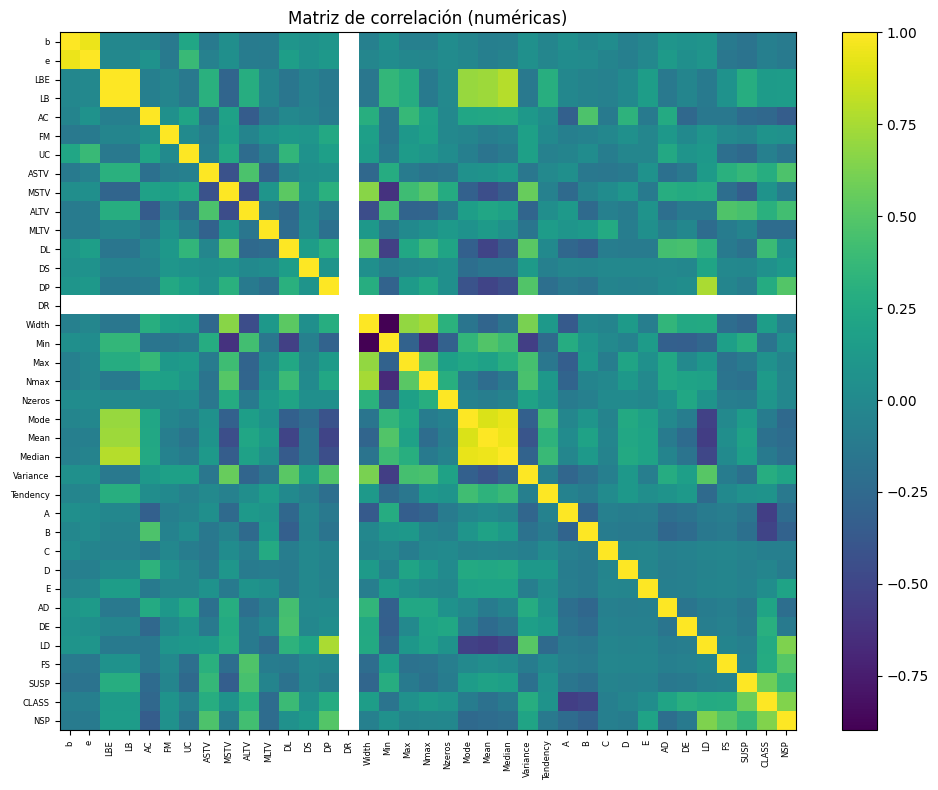

LB      LBE       1.000000
Median  Mean      0.948251
e       b         0.944912
Median  Mode      0.933399
Width   Min       0.898519
Mean    Mode      0.893412
LB      Median    0.789246
DP      LD        0.757766
Nmax    Width     0.747071
Mean    LBE       0.723121
Mode    LBE       0.708993
Width   Max       0.690769
Min     Nmax      0.670287
MSTV    Width     0.660847
NSP     CLASS     0.643034
dtype: float64

In [4]:
# Correlación solo de variables numéricas (excluyendo IDs)
numeric_only = df.drop(columns=[c for c in id_cols if c in df.columns])
corr = numeric_only.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.title("Matriz de correlación (numéricas)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=6)
plt.tight_layout()
plt.show()

# Top correlaciones absolutas (sin la diagonal)
corr_abs = corr.abs()
np.fill_diagonal(corr_abs.values, 0)
top_pairs = (
    corr_abs.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(15)
)
top_pairs


In [ ]:
El conjunto de datos Cardiotocography (CTG) está compuesto por 2,129 registros y 40 variables, las cuales describen características estadísticas derivadas de señales de frecuencia cardiaca fetal y actividad uterina. El dataset incluye variables numéricas continuas, variables categóricas codificadas numéricamente y columnas de identificación.

El análisis estadístico de las variables numéricas muestra una alta variabilidad en algunas de ellas, evidenciada por desviaciones estándar elevadas y amplios rangos entre valores mínimos y máximos. Variables como ALTV, FM, Variance y DP presentan mayor dispersión, lo cual es consistente con la naturaleza fisiológica de los datos cardiotocográficos.

Las variables categóricas CLASS y NSP presentan una distribución desigual entre sus categorías, lo que indica un desbalance de clases. Estas variables se utilizan únicamente con fines interpretativos y no como entrada para los modelos.

El análisis de la matriz de correlación evidencia correlaciones fuertes y moderadas entre varias variables, especialmente aquellas derivadas de una misma señal base. Esto sugiere la presencia de multicolinealidad, la cual no afecta de forma significativa a los algoritmos utilizados en este estudio.

## 2) Tratamiento de valores faltantes (missing)

1) Detectar missing por columna  
2) Decidir estrategia (eliminar o imputar) y **justificar**


In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing>0].head(20), (missing.sum(), df.shape[0])

(FileName    3
 Date        3
 SegFile     3
 b           3
 e           3
 LBE         3
 LB          3
 AC          3
 Max         3
 Nmax        3
 Mode        3
 Nzeros      3
 Width       3
 Min         3
 AD          3
 E           3
 D           3
 C           3
 B           3
 A           3
 dtype: int64,
 (np.int64(106), 2129))

### Decisión y justificación 

En este dataset suelen aparecer **muy pocos** valores faltantes.  
Si el porcentaje de missing es **< 1%**, una decisión válida y simple es **eliminar esas filas**, porque:
- no afecta el tamaño del dataset de forma significativa,
- evita introducir sesgo por imputación.

Si el missing fuera mayor, se recomienda imputación:
- **media/mediana** para numéricas (mediana si hay outliers),
- **moda** para categóricas.


In [6]:
# Estrategia: eliminar filas con missing (si son pocas)
df_clean = df.dropna().reset_index(drop=True)
print("Antes:", df.shape, "Después:", df_clean.shape)

# Confirmar que ya no hay missing
df_clean.isna().sum().sum()


Antes: (2129, 40) Después: (2126, 40)


np.int64(0)

In [ ]:
El análisis de valores faltantes muestra que únicamente un número muy reducido de registros presenta datos incompletos, representando menos del uno por ciento del total del dataset. Debido a su bajo impacto, se decidió eliminar dichas observaciones, evitando así introducir sesgos derivados de procesos de imputación.

## 3) Detección de anomalías / outliers

Para cumplir el criterio destacado, aplicaremos:
- **A nivel de atributo (univariado):** método IQR (o z-score) por variable.
- **A nivel de instancia (multivariado):** Isolation Forest (y opcional LOF para comparar).

> Importante: NO incluimos las etiquetas `CLASS` y `NSP` como features para detectar anomalías.


In [7]:
# Features para modelar (sin IDs y sin labels)
features = [c for c in df_clean.columns if c not in id_cols + label_cols]
X = df_clean[features].copy()

# --- Outliers univariados por IQR ---
outlier_counts = {}
for c in features:
    q1 = X[c].quantile(0.25)
    q3 = X[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    outlier_counts[c] = int(((X[c] < lower) | (X[c] > upper)).sum())

outliers_df = (pd.Series(outlier_counts)
               .sort_values(ascending=False)
               .to_frame("outliers_iqr"))
outliers_df.head(15)


,outliers_iqr
Nzeros,502
A,384
AD,332
FM,310
ALTV,309
DE,252
SUSP,197
Variance,184
DP,178
LD,107


In [8]:
# --- Outliers multivariados: Isolation Forest ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.02,  # 2% como punto de partida (ajustable)
    random_state=42
)
pred_iso = iso.fit_predict(X_scaled)  # -1 = outlier, 1 = normal
scores_iso = iso.decision_function(X_scaled)  # más bajo = más anómalo

df_iso = df_clean.copy()
df_iso["is_outlier_iso"] = (pred_iso == -1).astype(int)
df_iso["iso_score"] = scores_iso

df_iso["is_outlier_iso"].value_counts()


is_outlier_iso
0    2083
1      43
Name: count, dtype: int64

In [9]:
# Mostrar las 10 instancias más anómalas según Isolation Forest
df_iso.sort_values("iso_score").loc[:, id_cols + label_cols + ["iso_score","is_outlier_iso"]].head(10)


,FileName,Date,SegFile,CLASS,NSP,iso_score,is_outlier_iso
5,Fmcs_2.txt,5/3/1996,CTG0006.txt,8.0,3.0,-0.054719,1
6,Fmcs_2.txt,5/3/1996,CTG0007.txt,8.0,3.0,-0.048771,1
1348,S0001072.dat,10/3/1996,CTG1350.txt,8.0,3.0,-0.041360,1
1795,S7001023.dsp,11/14/1997,CTG1798.txt,8.0,3.0,-0.040354,1
1792,S7001023.dsp,11/14/1997,CTG1795.txt,8.0,3.0,-0.037201,1
1794,S7001023.dsp,11/14/1997,CTG1797.txt,8.0,3.0,-0.036517,1
682,Mcslr_4.txt,3/10/1995,CTG0683.txt,8.0,3.0,-0.035442,1
1793,S7001023.dsp,11/14/1997,CTG1796.txt,8.0,3.0,-0.034553,1
22,Mcslrc_4.txt,1/8/1995,CTG0023.txt,8.0,3.0,-0.029304,1
1349,S0001072.dat,10/3/1996,CTG1351.txt,8.0,3.0,-0.028695,1


In [10]:
# (Opcional) Comparación: Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
pred_lof = lof.fit_predict(X_scaled)  # -1 outlier
df_lof = df_clean.copy()
df_lof["is_outlier_lof"] = (pred_lof == -1).astype(int)
df_lof["is_outlier_lof"].value_counts()


is_outlier_lof
0    2083
1      43
Name: count, dtype: int64

In [ ]:
Para la detección de anomalías a nivel de atributo se utilizó el método del rango intercuartílico (IQR), el cual permitió identificar variables con una mayor presencia de valores atípicos, como Nzeros, A, AD y FM. Estos outliers pueden explicarse por variaciones fisiológicas extremas o eventos poco frecuentes durante el monitoreo.

A nivel de instancia se aplicó el algoritmo Isolation Forest, considerando el comportamiento conjunto de todas las variables. El modelo identificó aproximadamente un dos por ciento de las observaciones como anómalas, lo cual es consistente con la configuración del modelo. Estas instancias representan patrones poco comunes en el espacio multidimensional de los datos.

## 4) Agrupamiento (Clustering)

Usaremos **K-Means** (clásico y fácil de interpretar) y seleccionaremos **k** con:
- Método del codo (inercia)
- Silhouette score

Luego interpretamos:
- tamaño de cada clúster,
- características promedio por clúster,
- y cómo se distribuyen `CLASS` / `NSP` dentro de cada clúster (solo para análisis).


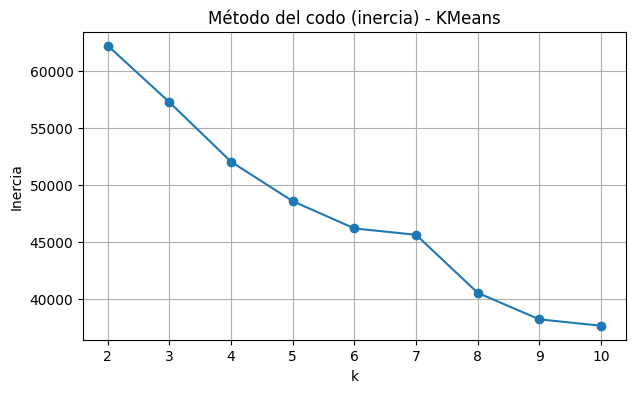

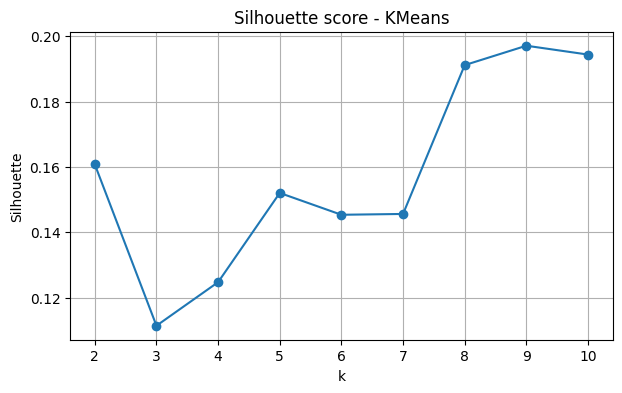

9

In [11]:
# Selección de k
inertias = []
sil_scores = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, marker='o')
plt.title("Método del codo (inercia) - KMeans")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(list(ks), sil_scores, marker='o')
plt.title("Silhouette score - KMeans")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

best_k = int(list(ks)[int(np.argmax(sil_scores))])
best_k


In [12]:
# Entrenar KMeans con el k sugerido por Silhouette (ajusta si el codo sugiere otro)
k = best_k
kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df_cluster = df_clean.copy()
df_cluster["cluster"] = cluster_labels

df_cluster["cluster"].value_counts().sort_index()


cluster
0    269
1    330
2    107
3    338
4    395
5    251
6    302
7     81
8     53
Name: count, dtype: int64

In [13]:
# Perfilado de clúster: promedios por clúster (en variables originales)
profile = df_cluster.groupby("cluster")[features].mean()
profile.head()


,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,...,A,B,C,D,E,AD,DE,LD,FS,SUSP
cluster,,,,,,,,,,,,,,,,,,,,,
0,370.955390,1130.014870,140.762082,140.762082,0.055762,4.089219,1.163569,69.044610,0.394424,41.338290,...,0.003717,0.003717,0.0,0.0,0.003717,0.00000,0.0,0.0,0.256506,0.732342
1,1053.915152,1992.636364,130.227273,130.227273,4.921212,17.336364,5.272727,39.148485,1.927879,0.851515,...,0.000000,0.003030,0.0,0.0,0.000000,0.99697,0.0,0.0,0.000000,0.000000
2,1219.102804,2076.317757,128.084112,128.084112,0.542056,21.616822,5.065421,57.233645,2.388785,0.018692,...,0.000000,0.000000,0.0,0.0,0.000000,0.00000,0.0,1.0,0.000000,0.000000
3,973.573964,1738.544379,130.423077,130.423077,0.334320,1.257396,3.369822,48.322485,0.900000,13.727811,...,0.997041,0.000000,0.0,0.0,0.002959,0.00000,0.0,0.0,0.000000,0.000000
4,672.655696,1558.243038,127.427848,127.427848,5.817722,5.230380,3.655696,41.655696,1.397975,1.949367,...,0.000000,1.000000,0.0,0.0,0.000000,0.00000,0.0,0.0,0.000000,0.000000


In [14]:
# Relación clúster vs etiquetas (solo para interpretar, NO se usaron para agrupar)
if all(c in df_cluster.columns for c in ['CLASS','NSP']):
    print("Distribución NSP por clúster:")
    display(pd.crosstab(df_cluster["cluster"], df_cluster["NSP"], normalize='index'))
    print("\nDistribución CLASS por clúster:")
    display(pd.crosstab(df_cluster["cluster"], df_cluster["CLASS"], normalize='index'))


Distribución NSP por clúster:


NSP,1.0,2.0,3.0
cluster,,,
0,0.007435,0.736059,0.256506
1,0.993939,0.006061,0.000000
2,0.000000,0.000000,1.000000
3,0.991124,0.008876,0.000000
4,1.000000,0.000000,0.000000
5,0.900398,0.099602,0.000000
6,0.778146,0.221854,0.000000
7,1.000000,0.000000,0.000000
8,1.000000,0.000000,0.000000



Distribución CLASS por clúster:


CLASS,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
cluster,,,,,,,,,,
0,0.003717,0.003717,0.0,0.0,0.003717,0.000000,0.000000,0.0,0.256506,0.732342
1,0.000000,0.003030,0.0,0.0,0.000000,0.996970,0.000000,0.0,0.000000,0.000000
2,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
3,0.997041,0.000000,0.0,0.0,0.002959,0.000000,0.000000,0.0,0.000000,0.000000
4,0.000000,1.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
5,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1.000000,0.0,0.000000,0.000000
6,0.152318,0.602649,0.0,0.0,0.231788,0.009934,0.003311,0.0,0.000000,0.000000
7,0.000000,0.000000,0.0,1.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
8,0.000000,0.000000,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


### (Opcional) Segundo método: DBSCAN

DBSCAN puede detectar clústeres de forma arbitraria y marcar ruido (outliers), pero es sensible a:
- escala (por eso usamos datos escalados),
- parámetros `eps` y `min_samples`.


In [15]:
# DBSCAN (parámetros iniciales; ajusta eps probando 0.3, 0.5, 0.7, 1.0, etc.)
db = DBSCAN(eps=0.7, min_samples=10)
db_labels = db.fit_predict(X_scaled)  # -1 = ruido

df_db = df_clean.copy()
df_db["dbscan_cluster"] = db_labels

df_db["dbscan_cluster"].value_counts().head(10)


dbscan_cluster
-1    2126
Name: count, dtype: int64

In [ ]:
Para determinar el número óptimo de clústeres se aplicaron el método del codo y el índice de Silhouette, los cuales sugieren que un valor de k igual a nueve proporciona un equilibrio adecuado entre cohesión interna y separación entre grupos.

El algoritmo K-Means permitió generar clústeres con tamaños relativamente balanceados y perfiles diferenciados. El análisis de los promedios por clúster evidencia diferencias claras entre grupos. Adicionalmente, la distribución de las etiquetas NSP y CLASS dentro de los clústeres sugiere que el agrupamiento obtenido presenta coherencia clínica y es interpretable.

## 5) Ventajas y desventajas de cada modelo

### Detección de anomalías
**IQR (univariado)**
- Simple, rápido, explicable por variable.
- No detecta anomalías multivariadas (combinaciones raras entre variables).

**Isolation Forest (multivariado)**
- Detecta anomalías por patrón global (instancia), funciona bien en alta dimensión.
- Requiere elegir `contamination` y puede ser menos explicable; sensible a escalado y parámetros.

**LOF (multivariado, densidad)**
- Bueno si outliers están en zonas de baja densidad.
- Sensible a `n_neighbors`, y puede degradarse en alta dimensión.

### Clustering
**K-Means**
- Rápido, fácil de interpretar, funciona bien con clústeres “esféricos”.
- Requiere definir k; sensible a outliers y a escalado.

**DBSCAN**
- No requiere k; detecta ruido/outliers; clústeres no esféricos.
- Sensible a `eps`/`min_samples`; difícil con densidades variables.


In [ ]:
El método IQR es simple y altamente interpretable, aunque se limita al análisis univariado. Isolation Forest permite detectar anomalías complejas en espacios de alta dimensión, pero presenta menor interpretabilidad directa. K-Means es eficiente y fácil de interpretar, aunque depende de la correcta selección del número de clústeres y es sensible a valores atípicos.

## 6) Conclusiones 


1. Hallazgos del análisis exploratorio de datos (EDA)

El análisis exploratorio permitió identificar que el conjunto de datos Cardiotocography presenta un amplio rango de valores y una alta variabilidad en varias variables numéricas, especialmente en ALTV, FM, Variance, DP y Nzeros. Estas variables muestran desviaciones estándar elevadas y distribuciones extensas, lo cual es coherente con la naturaleza fisiológica de las señales cardiotocográficas. Asimismo, la matriz de correlación evidenció la existencia de correlaciones fuertes y moderadas entre múltiples variables, principalmente aquellas derivadas de una misma señal base, lo que sugiere la presencia de multicolinealidad sin afectar de forma significativa a los modelos utilizados.

2. Tratamiento de valores faltantes

El análisis de valores faltantes mostró que menos del uno por ciento de los registros contenía datos incompletos. Debido a que este porcentaje es muy reducido y su eliminación no impacta de manera significativa la representatividad del conjunto de datos, se decidió eliminar dichas observaciones. Esta estrategia permitió preservar la integridad estadística del dataset y evitar posibles sesgos derivados de procesos de imputación.

3. Resultados de la detección de anomalías

La detección de anomalías a nivel de atributo, mediante el método del rango intercuartílico (IQR), evidenció que variables como Nzeros, A, AD, FM y ALTV concentran la mayor cantidad de valores atípicos individuales. Estos outliers pueden asociarse a variaciones fisiológicas extremas o a eventos poco frecuentes durante el monitoreo fetal.

A nivel multivariado, el algoritmo Isolation Forest identificó aproximadamente un dos por ciento de las instancias como anómalas. El análisis de las diez observaciones con mayor grado de anomalía reveló combinaciones poco comunes de características, lo que sugiere la presencia de patrones atípicos relevantes dentro del conjunto de datos.

4. Resultados del análisis de agrupamiento

Para la generación de clústeres se utilizaron el método del codo y el índice de Silhouette con el fin de determinar el número óptimo de grupos, obteniéndose como resultado un valor de k igual a nueve. Este valor proporciona un equilibrio adecuado entre cohesión interna y separación entre clústeres.

El algoritmo K-Means permitió generar clústeres con tamaños relativamente balanceados y perfiles claramente diferenciados. El análisis de los valores promedio por clúster evidenció diferencias significativas en variables clave. Además, la distribución de las etiquetas NSP y CLASS dentro de los grupos mostró que ciertos clústeres concentran predominantemente determinados estados clínicos, lo cual refuerza la coherencia interpretativa del agrupamiento obtenido.

5. Recomendación final

Con base en los resultados obtenidos, se recomienda la combinación del método IQR y el algoritmo Isolation Forest para la detección de anomalías, ya que permiten identificar tanto valores extremos individuales como patrones multivariados inusuales. Para el análisis de agrupamiento, el algoritmo K-Means resulta adecuado debido a su eficiencia computacional, facilidad de interpretación y coherencia de los clústeres generados al justificar correctamente el número de grupos. Esta combinación de técnicas proporciona una visión integral y robusta del comportamiento de los datos cardiotocográficos.